# IBM HR Employee Attrition Analysis

This notebook explores IBM HR employee attrition through data preparation, exploratory analysis, and predictive modeling. The models identify patterns in this dataset; their risk scores are exploratory and should not be treated as causal findings or employment decisions.

## 1. Setup

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load and Prepare Data

In [21]:
df = pd.read_csv("Dataset/IBM HR Analytics Employee Attrition & Performance.csv")
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


### Data Checks and Preparation

In [22]:
# Row & Columns
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}\n")
# Check Duplication
duplicate_count = df.duplicated().sum()
print(f"Duplicate Rows: {duplicate_count:,}\n")
# Columns data-types
df.dtypes

Rows: 1,470
Columns: 35

Duplicate Rows: 0



Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesL

In [23]:
# Check missing value
df.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

### Column Drop & Reason
- `EmployeeCount`, `Over18`, `StandardHours`: Same value in every row (1, "Y", 80), so they carry no information.
- `EmployeeNumber`: Unique ID. Used as the index, not as a feature.
- `DailyRate`, `HourlyRate`, `MonthlyRate`: Correlation with MonthlyIncome is near zero (see check below) and attrition does not vary across their quartiles. MonthlyIncome is kept as the pay measure.

In [24]:
# Column Drop
df = df[['EmployeeNumber', 'Age', 'Gender', 'MaritalStatus',
         'Education', 'EducationField', 'DistanceFromHome', 'Department',
         'JobRole', 'JobLevel', 'MonthlyIncome', 'PercentSalaryHike',
         'StockOptionLevel', 'BusinessTravel', 'OverTime',
         'NumCompaniesWorked', 'TotalWorkingYears', 'YearsAtCompany',
         'YearsInCurrentRole', 'YearsSinceLastPromotion',
         'YearsWithCurrManager', 'PerformanceRating',
         'TrainingTimesLastYear', 'EnvironmentSatisfaction',
         'JobInvolvement', 'JobSatisfaction',
         'RelationshipSatisfaction', 'WorkLifeBalance', 'Attrition']
        ].set_index('EmployeeNumber')


In [25]:
# Row & Columns
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}\n")

Rows: 1,470
Columns: 28



In [26]:
# Encoding
df['Attrition']= df['Attrition'].map({'Yes':1,'No':0})

In [27]:
df.head()

,Age,Gender,MaritalStatus,Education,EducationField,DistanceFromHome,Department,JobRole,JobLevel,MonthlyIncome,...,YearsSinceLastPromotion,YearsWithCurrManager,PerformanceRating,TrainingTimesLastYear,EnvironmentSatisfaction,JobInvolvement,JobSatisfaction,RelationshipSatisfaction,WorkLifeBalance,Attrition
EmployeeNumber,,,,,,,,,,,,,,,,,,,,,
1,41,Female,Single,2,Life Sciences,1,Sales,Sales Executive,2,5993,...,0,5,3,0,2,3,4,1,1,1
2,49,Male,Married,1,Life Sciences,8,Research & Development,Research Scientist,2,5130,...,1,7,4,3,3,2,2,4,3,0
4,37,Male,Single,2,Other,2,Research & Development,Laboratory Technician,1,2090,...,0,0,3,3,4,2,3,2,3,1
5,33,Female,Married,4,Life Sciences,3,Research & Development,Research Scientist,1,2909,...,3,0,3,3,4,3,3,3,3,0
7,27,Male,Married,1,Medical,2,Research & Development,Laboratory Technician,1,3468,...,2,2,3,3,1,3,2,4,3,0


In [28]:
df.tail()

,Age,Gender,MaritalStatus,Education,EducationField,DistanceFromHome,Department,JobRole,JobLevel,MonthlyIncome,...,YearsSinceLastPromotion,YearsWithCurrManager,PerformanceRating,TrainingTimesLastYear,EnvironmentSatisfaction,JobInvolvement,JobSatisfaction,RelationshipSatisfaction,WorkLifeBalance,Attrition
EmployeeNumber,,,,,,,,,,,,,,,,,,,,,
2061,36,Male,Married,2,Medical,23,Research & Development,Laboratory Technician,2,2571,...,0,3,3,3,3,4,4,3,3,0
2062,39,Male,Married,1,Medical,6,Research & Development,Healthcare Representative,3,9991,...,1,7,3,5,4,2,1,1,3,0
2064,27,Male,Married,3,Life Sciences,4,Research & Development,Manufacturing Director,2,6142,...,0,3,4,0,2,4,2,2,3,0
2065,49,Male,Married,3,Medical,2,Sales,Sales Executive,2,5390,...,0,8,3,3,4,2,2,4,2,0
2068,34,Male,Married,3,Medical,8,Research & Development,Laboratory Technician,2,4404,...,1,2,3,3,2,4,3,1,4,0


## 3. Exploratory Data Analysis

In [29]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.0,60.0
Education,1470.0,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.0,2.0,3.0,5.0
MonthlyIncome,1470.0,6502.931293,4707.956783,1009.0,2911.0,4919.0,8379.0,19999.0
PercentSalaryHike,1470.0,15.209524,3.659938,11.0,12.0,14.0,18.0,25.0
StockOptionLevel,1470.0,0.793878,0.852077,0.0,0.0,1.0,1.0,3.0
NumCompaniesWorked,1470.0,2.693197,2.498009,0.0,1.0,2.0,4.0,9.0
TotalWorkingYears,1470.0,11.279592,7.780782,0.0,6.0,10.0,15.0,40.0
YearsAtCompany,1470.0,7.008163,6.126525,0.0,3.0,5.0,9.0,40.0


### Survey Ratings

In [30]:
survey_columns = [
    "EnvironmentSatisfaction",
    "JobInvolvement",
    "JobSatisfaction",
    "RelationshipSatisfaction",
    "WorkLifeBalance"
]

survey_summary = (
    df[survey_columns]
    .mean()
    .sort_values(ascending=False)
    .to_frame("Mean Rating")
    .round(2)
)

# Interpret the mean rating
def interpret_rating(mean):
    if mean <= 1.75:
        return "Very Low / Very Negative"
    elif mean <= 2.50:
        return "Low / Negative"
    elif mean <= 3.25:
        return "Moderate / Neutral"
    else:
        return "High / Positive"

survey_summary["Interpretation"] = survey_summary["Mean Rating"].apply(interpret_rating)

display(survey_summary)

,Mean Rating,Interpretation
WorkLifeBalance,2.76,Moderate / Neutral
JobInvolvement,2.73,Moderate / Neutral
JobSatisfaction,2.73,Moderate / Neutral
EnvironmentSatisfaction,2.72,Moderate / Neutral
RelationshipSatisfaction,2.71,Moderate / Neutral


### Overall Attrition

In [31]:
total_employee_count = len(df)
attrition_count = df["Attrition"].sum()
attrition_rate = attrition_count / total_employee_count * 100

summary = pd.DataFrame({
    "Metric": ["Total Employees", "Attrition Count", "Attrition Rate"],
    "Value": [
        total_employee_count,
        attrition_count,
        f"{attrition_rate:.2f}%"
    ]
})

summary

,Metric,Value
0,Total Employees,1470
1,Attrition Count,237
2,Attrition Rate,16.12%


### Attrition Rate Analysis

#### Screening
- Screen every columns to detect which columns worth attention
- by how spread the data was

In [ ]:
# Screen every Column
cols = [c for c in df.columns if c != "Attrition"]
rows = []
for c in cols:
    s = df[c]
    # bin numeric columns with many unique values
    if s.dtype.kind in "if" and s.nunique() > 10:
        s = pd.qcut(s, 4, duplicates="drop")
    g = df.groupby(s, observed=True)["Attrition"].agg(["count", "mean"])
    g = g[g["count"] >= 30]            # ignore tiny groups
    rows.append({"Column": c,
                 "Lowest %": round(g["mean"].min() * 100, 1),
                 "Highest %": round(g["mean"].max() * 100, 1),
                 "Spread (pts)": round((g["mean"].max() - g["mean"].min()) * 100, 1)})

screen = pd.DataFrame(rows).sort_values("Spread (pts)", ascending=False)
screen

,Column,Lowest %,Highest %,Spread (pts)
7,JobRole,2.5,39.8,37.3
23,JobInvolvement,9.0,33.7,24.7
27,TenureBand,8.1,29.8,21.7
8,JobLevel,4.7,26.3,21.6
13,OverTime,10.4,30.5,20.1
28,IncomeBand,10.3,29.3,18.9
9,MonthlyIncome,10.3,29.3,18.9
21,TrainingTimesLastYear,9.2,27.8,18.5
26,WorkLifeBalance,14.2,31.2,17.0
0,Age,8.9,25.9,17.0


In [42]:
def attrition_by(col, data=df, sort=True):
    out = (
        data.groupby(col, observed=True)["Attrition"]
            .agg(Headcount="count", Leavers="sum", Rate="mean")
            .assign(Rate=lambda t: (t["Rate"] * 100).round(1))
            .rename(columns={"Rate": "Attrition Rate (%)"})
    )
    if sort:
        out = out.sort_values("Attrition Rate (%)", ascending=False)
    return out.reset_index()

df["TenureBand"] = pd.cut(df["YearsAtCompany"],
                          bins=[-1, 2, 5, 10, 50],
                          labels=["0-2", "3-5", "6-10", "10+"])

df["IncomeBand"] = pd.qcut(df["MonthlyIncome"], 4,
                           labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"])

display(
    attrition_by("JobRole"),
    attrition_by("JobInvolvement"),
    attrition_by("TenureBand", sort=False),   # keep natural order
    attrition_by("JobLevel"),
    attrition_by("OverTime"),
    attrition_by("IncomeBand", sort=False)
)

,JobRole,Headcount,Leavers,Attrition Rate (%)
0,Sales Representative,83,33,39.8
1,Laboratory Technician,259,62,23.9
2,Human Resources,52,12,23.1
3,Sales Executive,326,57,17.5
4,Research Scientist,292,47,16.1
5,Healthcare Representative,131,9,6.9
6,Manufacturing Director,145,10,6.9
7,Manager,102,5,4.9
8,Research Director,80,2,2.5


,JobInvolvement,Headcount,Leavers,Attrition Rate (%)
0,1,83,28,33.7
1,2,375,71,18.9
2,3,868,125,14.4
3,4,144,13,9.0


,TenureBand,Headcount,Leavers,Attrition Rate (%)
0,0-2,342,102,29.8
1,3-5,434,60,13.8
2,6-10,448,55,12.3
3,10+,246,20,8.1


,JobLevel,Headcount,Leavers,Attrition Rate (%)
0,1,543,143,26.3
1,3,218,32,14.7
2,2,534,52,9.7
3,5,69,5,7.2
4,4,106,5,4.7


,OverTime,Headcount,Leavers,Attrition Rate (%)
0,Yes,416,127,30.5
1,No,1054,110,10.4


,IncomeBand,Headcount,Leavers,Attrition Rate (%)
0,Q1 (lowest),369,108,29.3
1,Q2,366,52,14.2
2,Q3,367,39,10.6
3,Q4 (highest),368,38,10.3


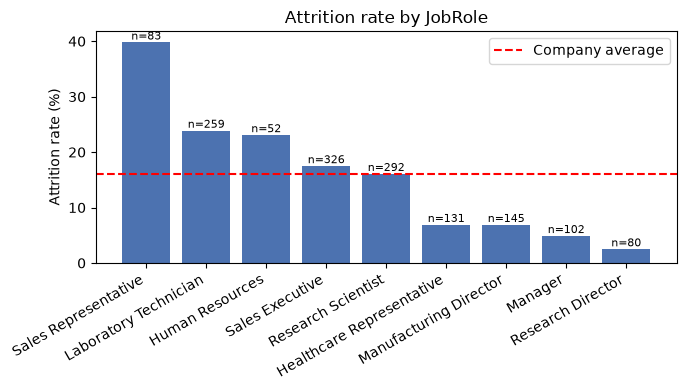

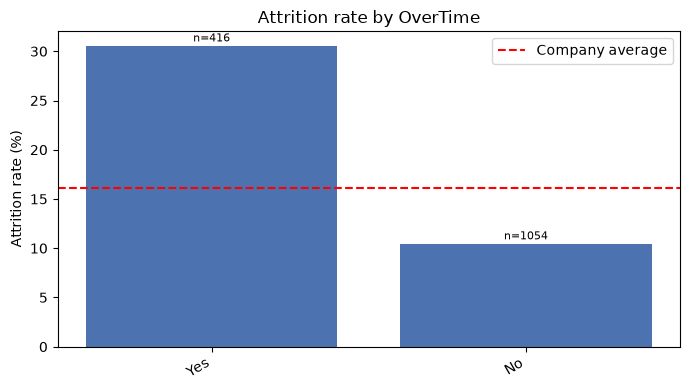

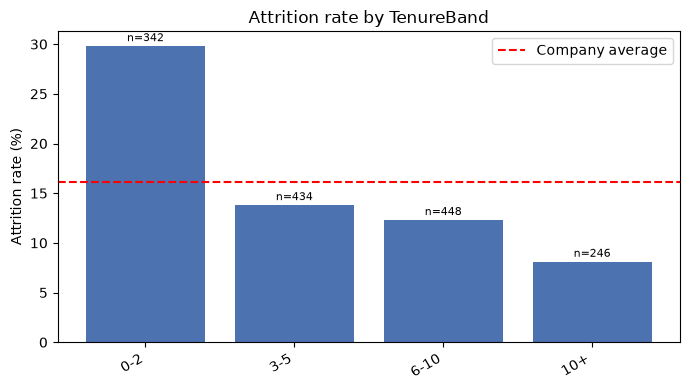

In [43]:
def plot_attrition(col, data=df, order=None):
    t = attrition_by(col, data, sort=(order is None))
    if order:
        t = t.set_index(col).loc[order].reset_index()

    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(t[col].astype(str), t["Attrition Rate (%)"], color="#4C72B0")
    ax.axhline(data["Attrition"].mean() * 100, color="red", ls="--", label="Company average")

    for b, n in zip(bars, t["Headcount"]):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.5,
                f"n={n}", ha="center", fontsize=8)

    ax.set_ylabel("Attrition rate (%)")
    ax.set_title(f"Attrition rate by {col}")
    ax.legend()
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
plot_attrition("JobRole")
plot_attrition("OverTime")
plot_attrition("TenureBand", order=["0-2", "3-5", "6-10", "10+"])

### Feature Correlations

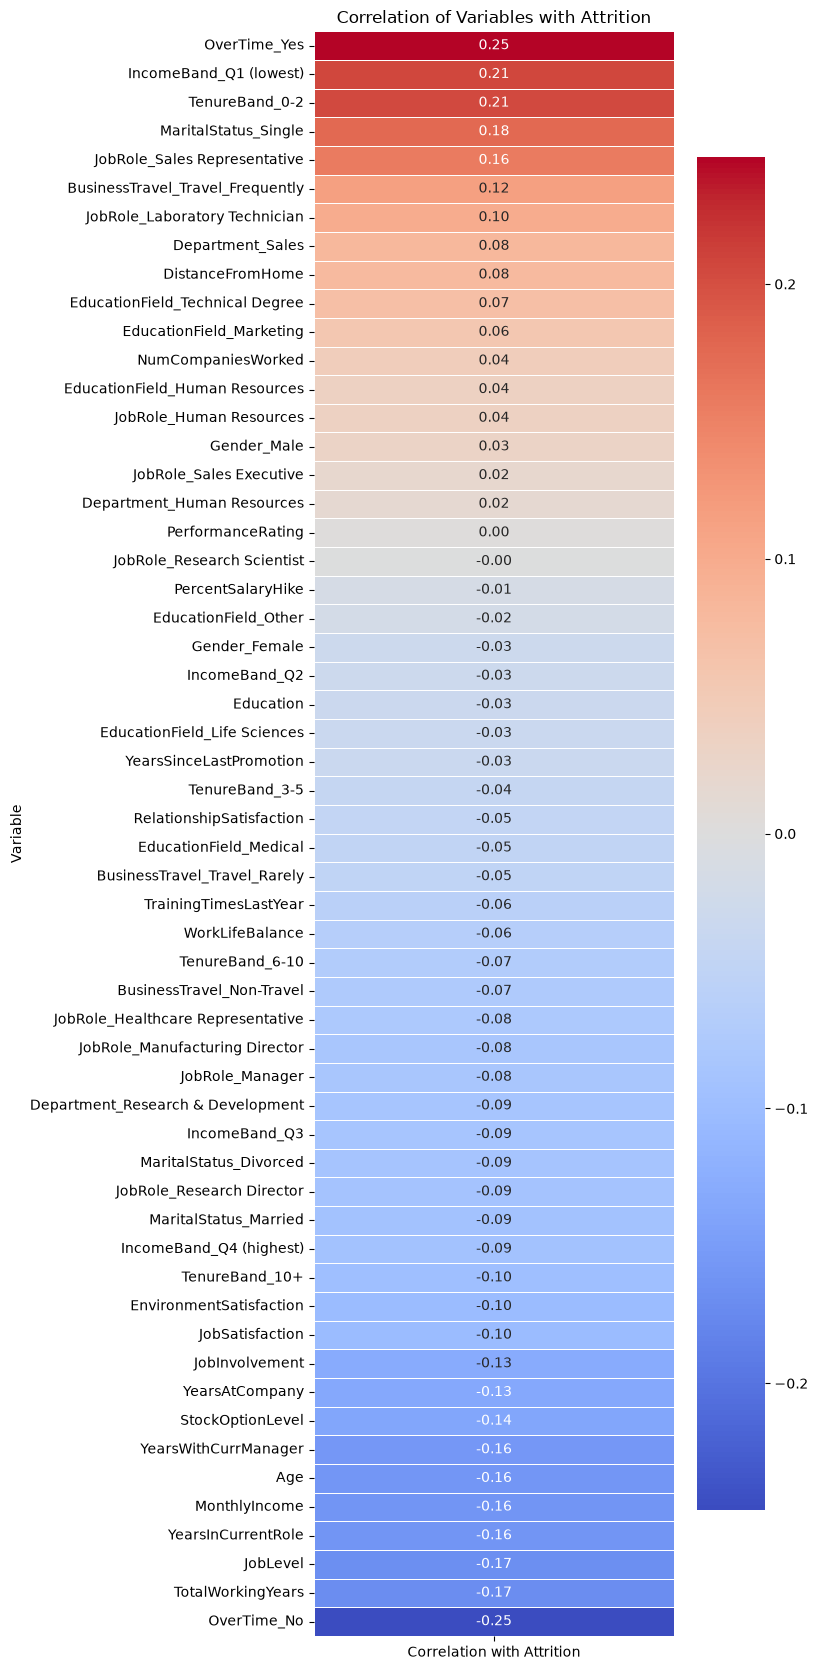

In [35]:
# One-hot encode categorical predictors, excluding the target and derived outlier flag
features = df.drop(columns=["Attrition", "outlier"], errors="ignore")
# Convert Category into dummy numeric
encoded_features = pd.get_dummies(features, drop_first=False, dtype=int)

# Correlation of each feature with Attrition
attrition_correlations = (
    encoded_features
    .corrwith(df["Attrition"])
    .dropna()
    .sort_values(ascending= False)
    .rename("Correlation with Attrition")
    .to_frame()
)

# display(attrition_correlations.round(2))

# Heatmap of feature correlations with Attrition
plt.figure(figsize=(8, max(6, len(attrition_correlations) * 0.3)))
sns.heatmap(
    attrition_correlations,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.4
)
plt.title("Correlation of Variables with Attrition")
plt.xlabel("")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

## 4. Optional Model Checks

### Logistic Regression

              precision    recall  f1-score   support

           0       0.93      0.80      0.86       247
           1       0.40      0.70      0.51        47

    accuracy                           0.78       294
   macro avg       0.67      0.75      0.68       294
weighted avg       0.85      0.78      0.80       294

ROC-AUC: 0.838


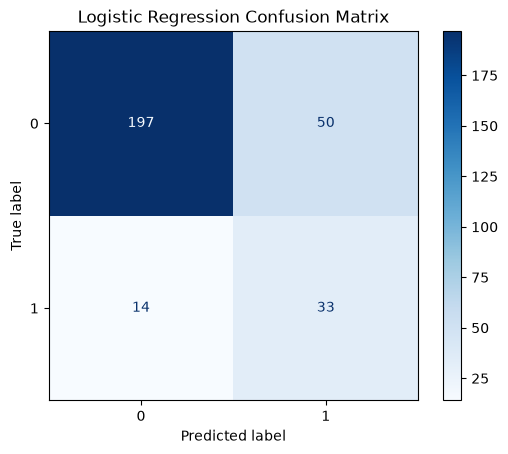

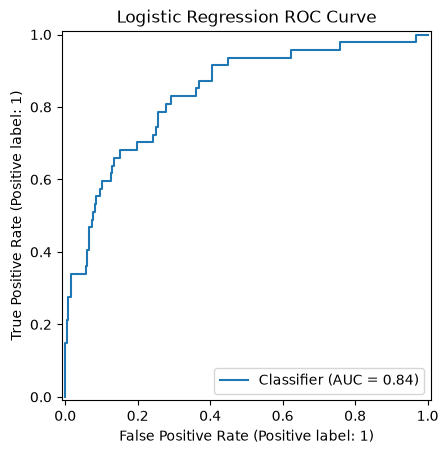

,EmployeeNumber,Attrition Risk (%),Actual Attrition
0,1273,98.996635,Yes
1,478,98.897873,Yes
2,959,97.555198,Yes
3,175,95.633088,Yes
4,702,95.247799,Yes
5,720,95.211944,Yes
6,1318,94.098675,Yes
7,1961,93.107019,No
8,1053,92.958117,Yes
9,4,90.318784,Yes


In [36]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

X = df.drop(columns="Attrition")
y = df["Attrition"]

numeric_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(exclude=np.number).columns

preprocessor = ColumnTransformer([
    ("numeric", StandardScaler(), numeric_features),
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.3f}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("Logistic Regression ROC Curve")
plt.show()

# Rank held-out employees by predicted probability of attrition
employee_risk = pd.DataFrame({
    "EmployeeNumber": X_test.index,
    "Attrition Risk (%)": y_prob * 100,
    "Actual Attrition": y_test.reindex(X_test.index).map({0: "No", 1: "Yes"}).to_numpy()
}).sort_values("Attrition Risk (%)", ascending=False)

display(employee_risk.head(20).reset_index(drop=True))